In [5]:
# ============================================================
# Driver Activity Recognition using CNN-LSTM
# State Farm Distracted Driver Detection
# Reduced Dataset (25% Drivers)
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM
)
from tensorflow.keras.models import Model

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

BASE_PATH = "/kaggle/input/competitions/state-farm-distracted-driver-detection"

TRAIN_PATH = os.path.join(
    BASE_PATH,
    "imgs",
    "train"
)

CSV_PATH = os.path.join(
    BASE_PATH,
    "driver_imgs_list.csv"
)

IMG_SIZE = 224
NUM_CLASSES = 10
SEQUENCE_LENGTH = 5
BATCH_SIZE = 64

print("TensorFlow:", tf.__version__)

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\nColumns:")
print(df.columns)

# Handle possible column names
if "classname" not in df.columns:
    if "class" in df.columns:
        df = df.rename(columns={"class": "classname"})

print("\nOriginal Images:", len(df))

# ============================================================
# USE ONLY 25% OF DRIVERS
# ============================================================

drivers = df["subject"].unique()

np.random.seed(42)

selected_drivers = np.random.choice(
    drivers,
    size=max(1, int(len(drivers) * 0.50)),
    replace=False
)

df = df[
    df["subject"].isin(selected_drivers)
].reset_index(drop=True)

print("Selected Drivers:", len(selected_drivers))
print("Images After Sampling:", len(df))

# ============================================================
# LABEL ENCODING
# ============================================================

class_map = {
    "c0": 0,
    "c1": 1,
    "c2": 2,
    "c3": 3,
    "c4": 4,
    "c5": 5,
    "c6": 6,
    "c7": 7,
    "c8": 8,
    "c9": 9
}

df["label"] = df["classname"].map(class_map)



TensorFlow: 2.19.0

Columns:
Index(['subject', 'classname', 'img'], dtype='object')

Original Images: 22424
Selected Drivers: 13
Images After Sampling: 10586


In [8]:
# ============================================================
# IMAGE LOADER
# ============================================================

def load_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = preprocess_input(
        img.astype(np.float32)
    )

    return img

# ============================================================
# FEATURE EXTRACTOR
# ============================================================

feature_extractor = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

feature_extractor.trainable = False

print("\nEfficientNet Loaded")

# ============================================================
# PREPARE IMAGE PATHS
# ============================================================

all_paths = []
all_names = []

for _, row in df.iterrows():

    path = os.path.join(
        TRAIN_PATH,
        row["classname"],
        row["img"]
    )

    all_paths.append(path)
    all_names.append(row["img"])

# ============================================================
# FEATURE EXTRACTION
# ============================================================

image_features = {}

print("\nExtracting Features...")

for start in tqdm(
    range(0, len(all_paths), BATCH_SIZE)
):

    batch_paths = all_paths[
        start:start + BATCH_SIZE
    ]

    batch_imgs = []

    for path in batch_paths:
        batch_imgs.append(
            load_image(path)
        )

    batch_imgs = np.array(
        batch_imgs,
        dtype=np.float32
    )

    features = feature_extractor.predict(
        batch_imgs,
        verbose=0
    )

    for img_name, feat in zip(
        all_names[start:start + BATCH_SIZE],
        features
    ):
        image_features[img_name] = feat

print("Feature Extraction Complete")

# ============================================================
# CREATE FEATURE SEQUENCES
# ============================================================

X = []
y = []
groups = []

print("\nCreating Sequences...")

for driver in df["subject"].unique():

    driver_df = df[
        df["subject"] == driver
    ]

    for cls in driver_df["classname"].unique():

        temp = driver_df[
            driver_df["classname"] == cls
        ].copy()

        temp = temp.sort_values(
            by="img"
        )

        imgs = temp["img"].tolist()

        if len(imgs) < SEQUENCE_LENGTH:
            continue

        for i in range(
            len(imgs) - SEQUENCE_LENGTH + 1
        ):

            seq = imgs[
                i:i + SEQUENCE_LENGTH
            ]

            seq_features = []

            for img_name in seq:
                seq_features.append(
                    image_features[img_name]
                )

            X.append(seq_features)

            y.append(
                class_map[cls]
            )

            groups.append(driver)

X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

groups = np.array(groups)

print("\nSequence Shape:", X.shape)
print("Labels Shape:", y.shape)




EfficientNet Loaded

Extracting Features...


 99%|█████████▉| 165/166 [02:15<00:00,  1.85it/s]2026-05-29 06:44:22.133498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 06:44:22.275666: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 06:44:22.610210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 06:44:22.751429: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 

Feature Extraction Complete

Creating Sequences...

Sequence Shape: (10068, 5, 1280)
Labels Shape: (10068,)


In [9]:
# ============================================================
# DRIVER-WISE TRAIN TEST SPLIT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups
    )
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)

# ============================================================
# ONE HOT
# ============================================================

y_train_cat = to_categorical(
    y_train,
    NUM_CLASSES
)

y_test_cat = to_categorical(
    y_test,
    NUM_CLASSES
)

# ============================================================
# CNN BASELINE
# Last Frame Only
# ============================================================

X_train_cnn = X_train[:, -1]
X_test_cnn = X_test[:, -1]

cnn_input = Input(shape=(1280,))

x = Dense(
    512,
    activation="relu"
)(cnn_input)

x = Dropout(0.5)(x)

cnn_output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

cnn_model = Model(
    cnn_input,
    cnn_output
)

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining CNN Baseline...")

cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

cnn_pred = cnn_model.predict(
    X_test_cnn
)

cnn_classes = np.argmax(
    cnn_pred,
    axis=1
)

cnn_acc = accuracy_score(
    y_test,
    cnn_classes
)

cnn_logloss = log_loss(
    y_test_cat,
    cnn_pred
)

print("\nCNN Accuracy :", cnn_acc)
print("CNN LogLoss  :", cnn_logloss)

# ============================================================
# CNN-LSTM
# ============================================================

inputs = Input(
    shape=(
        SEQUENCE_LENGTH,
        1280
    )
)

x = LSTM(
    128,
    return_sequences=False
)(inputs)

x = Dropout(0.5)(x)

x = Dense(
    128,
    activation="relu"
)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

cnn_lstm = Model(
    inputs,
    outputs
)

cnn_lstm.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm.summary()

print("\nTraining CNN-LSTM...")

cnn_lstm.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)




Train: (8104, 5, 1280)
Test : (1964, 5, 1280)

Training CNN Baseline...
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7635 - loss: 0.8308 - val_accuracy: 0.2776 - val_loss: 2.3082
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9622 - loss: 0.1801 - val_accuracy: 0.2918 - val_loss: 2.2030
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9806 - loss: 0.0940 - val_accuracy: 0.2869 - val_loss: 2.5612
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9874 - loss: 0.0653 - val_accuracy: 0.3004 - val_loss: 2.7147
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.0504 - val_accuracy: 0.3023 - val_loss: 2.6627
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0367 - val_accuracy: 0.2776 - val_loss: 3.3572
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9946 - loss: 0.0281 - val_accuracy: 0.2899 - val_loss: 3.3836
Epoch 8/10
102/102 ━━━━━━━━━━━

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 5, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,210 (2.82 MB)

 Trainable params: 739,210 (2.82 MB)

 Non-trainable params: 0 (0.00 B)


Training CNN-LSTM...
Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8160 - loss: 0.5960 - val_accuracy: 0.1851 - val_loss: 4.4956
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9961 - loss: 0.0172 - val_accuracy: 0.3411 - val_loss: 3.5042
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.3627 - val_loss: 3.9222
Epoch 4/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 9.9163e-04 - val_accuracy: 0.3664 - val_loss: 3.6569
Epoch 5/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9750 - loss: 0.0739 - val_accuracy: 0.2949 - val_loss: 3.8185
Epoch 6/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9941 - loss: 0.0220 - val_accuracy: 0.3325 - val_loss: 4.3188
Epoch 7/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.2844 - val_loss: 5.5703
Epoch 8/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss:

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

CNN-LSTM Accuracy : 0.6013238289205702
CNN-LSTM LogLoss  : 2.8994962075803525

Model Comparison
      Model  Accuracy   LogLoss
0       CNN  0.600305  1.887614
1  CNN-LSTM  0.601324  2.899496


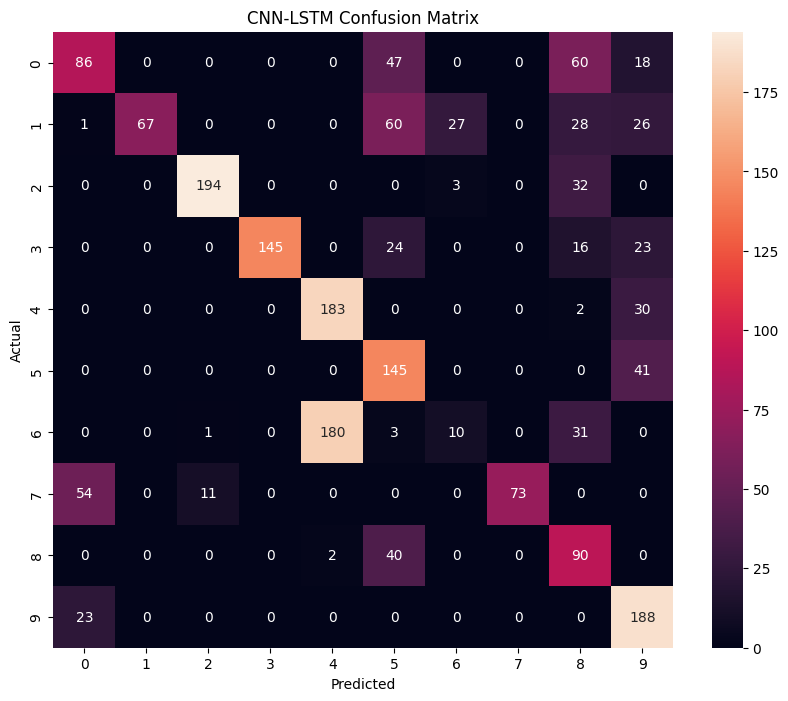


Classification Report

              precision    recall  f1-score   support

           0       0.52      0.41      0.46       211
           1       1.00      0.32      0.49       209
           2       0.94      0.85      0.89       229
           3       1.00      0.70      0.82       208
           4       0.50      0.85      0.63       215
           5       0.45      0.78      0.57       186
           6       0.25      0.04      0.08       225
           7       1.00      0.53      0.69       138
           8       0.35      0.68      0.46       132
           9       0.58      0.89      0.70       211

    accuracy                           0.60      1964
   macro avg       0.66      0.60      0.58      1964
weighted avg       0.66      0.60      0.58      1964


Temporal Contribution Improvement = 0.10%
Temporal information improved recognition.

Models Saved Successfully


In [10]:
# ============================================================
# EVALUATION
# ============================================================

lstm_pred = cnn_lstm.predict(
    X_test
)

lstm_classes = np.argmax(
    lstm_pred,
    axis=1
)

lstm_acc = accuracy_score(
    y_test,
    lstm_classes
)

lstm_logloss = log_loss(
    y_test_cat,
    lstm_pred
)

print("\nCNN-LSTM Accuracy :", lstm_acc)
print("CNN-LSTM LogLoss  :", lstm_logloss)

# ============================================================
# COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "CNN",
        "CNN-LSTM"
    ],
    "Accuracy": [
        cnn_acc,
        lstm_acc
    ],
    "LogLoss": [
        cnn_logloss,
        lstm_logloss
    ]
})

print("\nModel Comparison")
print(comparison)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    lstm_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "CNN-LSTM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        lstm_classes
    )
)

# ============================================================
# TEMPORAL CONTRIBUTION ANALYSIS
# ============================================================

improvement = (
    lstm_acc - cnn_acc
) * 100

print(
    f"\nTemporal Contribution Improvement = "
    f"{improvement:.2f}%"
)

if lstm_acc > cnn_acc:
    print(
        "Temporal information improved recognition."
    )
else:
    print(
        "Single-frame spatial information was sufficient."
    )

# ============================================================
# SAVE MODELS
# ============================================================

cnn_model.save("cnn_baseline.h5")

cnn_lstm.save("cnn_lstm_model.h5")

print("\nModels Saved Successfully")